<a href="https://colab.research.google.com/github/KevinMascarenhas/Analise_de_dados_treinos_e_estudos/blob/main/An%C3%A1liseViagensMinist%C3%A9rio_da_transparencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Carregando os dados

In [ ]:
caminho_dados = "/content/drive/MyDrive/Colab Notebooks/AD/2023_Viagem.csv"

# Abrindo a tabela #

In [ ]:
import pandas as pd

df_viagens = pd.read_csv(caminho_dados, encoding="Windows-1252", sep=";", decimal=",")
pd.set_option('display.max_columns', None)

In [ ]:
df_viagens["Nome do órgão superior"].str.replace('Ministério', 'Min.')

,Nome do órgão superior
0,Min. da Educação
1,Min. da Educação
2,Min. da Defesa
3,Min. da Educação
4,Min. da Defesa
...,...
826984,Sem informação
826985,Sem informação
826986,Sem informação
826987,Sem informação


# Calculando despesas

In [ ]:
df_viagens['Despesas'] = df_viagens['Valor devolução'] + df_viagens['Valor passagens'] + df_viagens['Valor diárias'] + df_viagens['Valor outros gastos']

df_viagens.head()

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas
0,17821923,000001/23-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26352,Fundação Universidade Federal do ABC,***.875.238-**,PRISCILA LEAL DA SILVA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,01/01/2023,02/12/2023,Loughborough/Reino Unido,Intercâmbio acadêmico PCDP anterior 07/21-3C,0.00,0.00,0.0,0.00,0.00
1,18236583,000018/23,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,CAMILLA DUARTE DA SILVA,BIBLIOTECARIO-DOCUMENTALISTA,-1,Sem informação,16/01/2023,28/02/2024,Rio de Janeiro/RJ,Afastamento para pós-graduação stricto sensu n...,0.00,0.00,0.0,0.00,0.00
2,18288418,000007/23-1C,Realizada,SIM,Por necessidade do serviço.,52000,Ministério da Defesa,52121,Comando do Exército,***.621.358-**,ANDRE LUIS COSTA PITANGUEIRA,NaN,OfSuperior,OfSuperior,10/01/2023,29/01/2023,Nova York/Estados Unidos da América,Participar da revisão do COE Manual (Contingen...,39565.70,7434.13,0.0,1095.35,48095.18
3,18296348,000070/23,Realizada,SIM,A efetivação do empenho no Siafi e a respectiv...,26000,Ministério da Educação,26406,Instituto Federal do Espírito Santo,***.407.547-**,LIDIANY MIRANDA FERRAZ NUNES,AUXILIAR DE BIBLIIOTECA,-1,Sem informação,05/02/2023,10/02/2023,Vitória/ES,Participação das aulas de Mestrado Interinstit...,1013.96,0.00,0.0,0.00,1013.96
4,18302983,000001/23,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52111,Comando da Aeronáutica,***.855.388-**,GREGOR GASPAR,NaN,OfIntermed,OfIntermed,01/01/2023,07/07/2023,Gotemburgo/Suécia,PARTICIPAR DO CURSO DE PILOTO DE GRIPEN C/D.,0.00,14903.10,0.0,0.00,14903.10


In [ ]:
despesas_por_orgao = df_viagens.groupby('Cargo')['Despesas'].sum()
display(despesas_por_orgao)

,Despesas
Cargo,
AAD-AUX DE RECURSOS MATERIAIS,17960.50
AAD-AUXILIAR ADMINISTRATIVO,1620.65
AAD-AUXILIAR DE OPERACOES,55813.76
AAD-AUXILIAR DE RECURSOS FINANCEIROS,31091.89
AAD-OPERADOR DE MICROCOMPUTADOR,1186.47
...,...
VICE-PRESIDENTE DA REPUBLICA,14136.40
VIDREIRO,0.00
VIGILANTE,747588.74


In [ ]:
proporção_por_cargo = df_viagens['Cargo'].value_counts(normalize=True) * 100
display(proporção_por_cargo)

,proportion
Cargo,
Informações protegidas por sigilo,23.403160
PROFESSOR DO MAGISTERIO SUPERIOR,10.802646
PROFESSOR ENS BASICO TECN TECNOLOGICO,7.418728
CONTRATADO LEI 8745/93 - NI,3.521104
AUDITOR FISCAL FEDERAL AGROPECUARIO,3.282563
...,...
FISICO - 40H,0.000198
PROFISSIONAL TECNICO SUPERIOR II,0.000198
ARTIFICE DE ESTRUTURA DE OBRAS E METALUR,0.000198


In [ ]:
df_presidencia = df_viagens[df_viagens['Nome do órgão superior'] == 'Presidência da República']
display(df_presidencia.head())

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas
5087,18630684,000002/23-1C,Realizada,SIM,"Missão de forma inopinada, repassada à assesso...",20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.272.257-**,ODIMAR RAFAEL MAIA,NaN,CCX-0213,CCX-0213,02/01/2023,05/01/2023,Maceió/AL,1. 'Conforme o previsto no Decreto nº 6.381 de...,1369.23,3080.88,0.0,1349.63,5799.74
6310,18632565,000001/23,Realizada,SIM,Tendo em vista nos encontrarmos no início do e...,20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.514.137-**,CARLOS JOSE RUSSO ASSUMPCAO PENTEADO,NaN,CCX-0118,CCX-0118,17/01/2023,22/01/2023,Curitiba/PR,"Representar o GSI/PR, conforme agenda a seguir...",2502.50,1304.38,0.0,0.00,3806.88
6322,18632588,000003/23,Realizada,SIM,"Somente na manhã de hoje, 04.01.23, ficou defi...",20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.272.257-**,ODIMAR RAFAEL MAIA,NaN,CCX-0213,CCX-0213,05/01/2023,05/01/2023,Brasília/DF,'Conforme o previsto no Decreto nº 6.381 de 27...,0.00,2006.47,0.0,0.00,2006.47
6343,18632628,000004/23,Realizada,SIM,A solicitação em caráter de urgência se faz de...,20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.835.708-**,MICHAEL PEREIRA FLORES,NaN,CCX-0207,CCX-0207,01/01/2023,01/01/2023,Itu/SP,Conforme o previsto no Decreto nº 6.381 de 27 ...,150.45,0.00,0.0,0.00,150.45
6357,18632648,000005/23,Realizada,SIM,A solicitação em caráter de urgência se faz de...,20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.467.528-**,ANTONIO MARCOS LUCIANO,NaN,CCX-0205,CCX-0205,01/01/2023,01/01/2023,Itu/SP,Conforme o previsto no Decreto nº 6.381 de 27 ...,150.45,0.00,0.0,0.00,150.45


In [ ]:
despesa_por_cargo_por_orgao = df_viagens.groupby(['Cargo', 'Motivo', 'Nome do órgão superior'])['Despesas'].sum()
despesa_por_cargo_por_orgao = despesa_por_cargo_por_orgao.sort_values(ascending=False)
display(despesa_por_cargo_por_orgao)

Cargo                              Motivo                                                                                                                                                                                                                                                                                                               Nome do órgão superior                        
Informações protegidas por sigilo  Informação protegida por sigilo nos termos da legislação vigente                                                                                                                                                                                                                                                     Ministério da Justiça e Segurança Pública         3.248445e+08
                                                                                                                                                                                                                                                                                                                                                        Sem informação                                    3.865846e+07
                                                                                                                                                                                                                                                                                                                                                        Ministério do Meio Ambiente e Mudança do Clima    7.145027e+06
                                                                                                                                                                                                                                                                                                                                                        Presidência da República                          3.177935e+06
TECNICO DO SEGURO SOCIAL           Ação de Produtividade de análise de benefício: Participação na Oficina de Reconhecimento de Direito, conforme projeto constante no SEI 35014.117286/2023-91, aprovado pela DIRBEN.                                                                                                                                   Ministério da Previdência Social                  1.694393e+06
                                                                                                                                                                                                                                                                                                                                                                                                              ...     
PSICOLOGO AREA                     Participação no VI Encontro Nacional da EJA-EPT (PROEJA) da Rede Federal de Educação. Observação: o registro da viagem foi realizado antes de sua execução, mas por equívoco, no órgão PROEN - Pró-Reitoria de Ensino. Por esse motivo está sendo registrado no órgão Diretoria Sistêmica após o período da viagem.  Ministério da Educação                            0.000000e+00
PROFESSOR DO MAGISTERIO SUPERIOR   Deslocamento para o município de Conceição da Barra / ES, para coletar dados para o estudo intitulado 'Conexões e Diálogos: Plantas Medicinais, Práticas Integrativas, Ancestralidade no Cuidado e Saberes Tradicionais', aprovada no EDITAL FAPES Nº 12/2022 - UNIVERSAL EXTENSÃO.                                  Ministério da Educação                            0.000000e+00
                                   Deslocamento para participar na I Jornada Internacional Jurídica, Projeto de Extensão Registrado no Guri, Código 2677. De 08 a 10/11/2023.                                                                                                                                                                           Ministéri

In [ ]:
despesas_por_funcao_top_10 = df_viagens.groupby('Cargo')['Despesas'].sum().nlargest(10)
display(despesas_por_funcao_top_10)

# Cargos protegidos por sigilo foram os que mais tiveram despesas com viagens com verba pública.

,Despesas
Cargo,
Informações protegidas por sigilo,3.748302e+08
PROFESSOR DO MAGISTERIO SUPERIOR,1.119242e+08
PROFESSOR ENS BASICO TECN TECNOLOGICO,5.305428e+07
TECNICO DO SEGURO SOCIAL,4.631728e+07
ANALISTA AMBIENTAL,3.574400e+07
AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,2.474291e+07
ESP EM REGULACAO E VIGILANCIA SANITARIA,2.462539e+07
AUDITOR FISCAL FEDERAL AGROPECUARIO,2.457351e+07
CONTRATADO LEI 8745/93 - NI,1.780315e+07


In [ ]:
despesas_sigilosas = despesas_por_orgao[despesas_por_orgao.index == 'Informações protegidas por sigilo']
display(despesas_sigilosas)

,Despesas
Cargo,
Informações protegidas por sigilo,3.748302e+08


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
df_viagens.groupby("Cargo")["Despesas"].sum().sort_values(ascending=False)

,Despesas
Cargo,
Informações protegidas por sigilo,374830186.93
PROFESSOR DO MAGISTERIO SUPERIOR,111924241.48
PROFESSOR ENS BASICO TECN TECNOLOGICO,53054282.03
TECNICO DO SEGURO SOCIAL,46317278.56
ANALISTA AMBIENTAL,35743999.19
...,...
AUXILIAR - AUXILIAR DE SERVICOS GERAIS,0.00
CENOTECNICO,0.00
TECNICO EM GEOLOGIA,0.00


In [ ]:
df_viagens.groupby("Cargo")['Despesas'].mean().reset_index().sort_values(by='Despesas', ascending=False)
# Apesar dos maiores custos terem sido de "Informações protegidas por sigilo", as maiores médias são dos cargos de Segundo Tenente.

,Cargo,Despesas
615,SEGUNDO TENENTE,40482.60
325,DELEGADO DE POLICIA - PRIMEIRA CLASSE,34105.32
616,SEGUNDO-TENENTE,19823.43
480,MINISTRO DE PRIMEIRA CLASSE,19197.35
800,TERCEIRO SARGENTO,19184.20
...,...,...
454,LOCUTOR,0.00
723,TECNICO EM GEOLOGIA,0.00
733,TECNICO EM METALURGIA,0.00
301,CENOTECNICO,0.00


In [ ]:
viagens_por_cargo = (df_viagens['Cargo'].value_counts(normalize=True) * 100).rename('Porcentagem de Viagens Por Cargo (%)').reset_index()

In [ ]:
filtro_mais_de_um_porcento = viagens_por_cargo['Porcentagem de Viagens Por Cargo (%)'] > 1
display(viagens_por_cargo[filtro_mais_de_um_porcento])

,Cargo,Porcentagem de Viagens Por Cargo (%)
0,Informações protegidas por sigilo,23.40
1,PROFESSOR DO MAGISTERIO SUPERIOR,10.80
2,PROFESSOR ENS BASICO TECN TECNOLOGICO,7.42
3,CONTRATADO LEI 8745/93 - NI,3.52
4,AUDITOR FISCAL FEDERAL AGROPECUARIO,3.28
5,ANALISTA AMBIENTAL,2.69
6,ASSISTENTE EM ADMINISTRAçãO,2.31
7,TECNICO INFOR GEOGRAFICAS E ESTATISTICA,2.15
8,TECNICO DO SEGURO SOCIAL,2.11
9,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,2.00


In [ ]:
filtro_seguro_social = viagens_por_cargo['Cargo'].str.endswith('SEGURO SOCIAL')
display(viagens_por_cargo[filtro_seguro_social])

,Cargo,Porcentagem de Viagens Por Cargo (%)
8,TECNICO DO SEGURO SOCIAL,2.11
13,ANALISTA DO SEGURO SOCIAL,1.27


In [ ]:
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("Cargo não informado")
df_viagens.groupby('Cargo')['Despesas'].sum().sort_values(ascending=False)
filtro_valores_milionarios = (df_viagens.groupby('Cargo')['Despesas'].sum().sort_values(ascending=False)) > 1_000_000
display(filtro_valores_milionarios.nlargest(116))
# de cargo não informado (NaN) até Técnico de Contabilidade, 115 cargos diferentes realizaram gastos milionários.

,Despesas
Cargo,
Cargo não informado,True
Informações protegidas por sigilo,True
PROFESSOR DO MAGISTERIO SUPERIOR,True
PROFESSOR ENS BASICO TECN TECNOLOGICO,True
TECNICO DO SEGURO SOCIAL,True
...,...
PESQUISADOR-A,True
AUDITOR,True
PROFESSOR MAGISTERIO SUPERIOR-SUBSTITUTO,True


In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas
0,17821923,000001/23-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26352,Fundação Universidade Federal do ABC,***.875.238-**,PRISCILA LEAL DA SILVA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,01/01/2023,02/12/2023,Loughborough/Reino Unido,Intercâmbio acadêmico PCDP anterior 07/21-3C,0.00,0.00,0.00,0.00,0.00
1,18236583,000018/23,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,CAMILLA DUARTE DA SILVA,BIBLIOTECARIO-DOCUMENTALISTA,-1,Sem informação,16/01/2023,28/02/2024,Rio de Janeiro/RJ,Afastamento para pós-graduação stricto sensu n...,0.00,0.00,0.00,0.00,0.00
2,18288418,000007/23-1C,Realizada,SIM,Por necessidade do serviço.,52000,Ministério da Defesa,52121,Comando do Exército,***.621.358-**,ANDRE LUIS COSTA PITANGUEIRA,Cargo não informado,OfSuperior,OfSuperior,10/01/2023,29/01/2023,Nova York/Estados Unidos da América,Participar da revisão do COE Manual (Contingen...,39565.70,7434.13,0.00,1095.35,48095.18
3,18296348,000070/23,Realizada,SIM,A efetivação do empenho no Siafi e a respectiv...,26000,Ministério da Educação,26406,Instituto Federal do Espírito Santo,***.407.547-**,LIDIANY MIRANDA FERRAZ NUNES,AUXILIAR DE BIBLIIOTECA,-1,Sem informação,05/02/2023,10/02/2023,Vitória/ES,Participação das aulas de Mestrado Interinstit...,1013.96,0.00,0.00,0.00,1013.96
4,18302983,000001/23,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52111,Comando da Aeronáutica,***.855.388-**,GREGOR GASPAR,Cargo não informado,OfIntermed,OfIntermed,01/01/2023,07/07/2023,Gotemburgo/Suécia,PARTICIPAR DO CURSO DE PILOTO DE GRIPEN C/D.,0.00,14903.10,0.00,0.00,14903.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826984,2023001618,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.748.269-**,BIANCA VIANA KIVEL,ANALISTA DO BANCO CENTRAL,-1,Sem informação,05/12/2023,06/12/2023,Sem informação,Participar de tratativas nos locais das reuniõ...,606.89,3331.29,0.00,0.00,3938.18
826985,2023001619,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.231.806-**,LUCAS ALVES FREIRE,PROCURADOR DO BANCO CENTRAL,-1,Sem informação,11/12/2023,13/12/2023,Sem informação,Participar da reunião do COPOM .,1089.00,1837.18,0.00,0.00,2926.18
826986,2023001628,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.632.011-**,SERGIO BOTELHO,TECNICO DO BANCO CENTRAL,-1,Sem informação,07/12/2023,08/12/2023,Sem informação,Acompanhamento do Presidente do BC - São Paulo,734.13,4555.95,0.00,0.00,5290.08
826987,2023001631,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.407.445-**,NELSON CAMPOS REIS JUNIOR,TECNICO DO BANCO CENTRAL,-1,Sem informação,11/12/2023,11/12/2023,Sem informação,Acompanhamento do Presidente - São Paulo.,319.28,3745.53,0.00,400.00,4464.81


In [ ]:
df_viagens["Período - Data de início"] = pd.to_datetime(df_viagens["Período - Data de início"], format="%d/%m/%Y")
df_viagens["Período - Data de fim"] = pd.to_datetime(df_viagens["Período - Data de fim"], format="%d/%m/%Y")


In [ ]:
df_viagens["Dias de Viagem"] = - (df_viagens["Período - Data de início"] - df_viagens["Período - Data de fim"]).dt.days

In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Dias de Viagem
0,17821923,000001/23-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26352,Fundação Universidade Federal do ABC,***.875.238-**,PRISCILA LEAL DA SILVA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2023-01-01,2023-12-02,Loughborough/Reino Unido,Intercâmbio acadêmico PCDP anterior 07/21-3C,0.00,0.00,0.00,0.00,0.00,335
1,18236583,000018/23,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,CAMILLA DUARTE DA SILVA,BIBLIOTECARIO-DOCUMENTALISTA,-1,Sem informação,2023-01-16,2024-02-28,Rio de Janeiro/RJ,Afastamento para pós-graduação stricto sensu n...,0.00,0.00,0.00,0.00,0.00,408
2,18288418,000007/23-1C,Realizada,SIM,Por necessidade do serviço.,52000,Ministério da Defesa,52121,Comando do Exército,***.621.358-**,ANDRE LUIS COSTA PITANGUEIRA,Cargo não informado,OfSuperior,OfSuperior,2023-01-10,2023-01-29,Nova York/Estados Unidos da América,Participar da revisão do COE Manual (Contingen...,39565.70,7434.13,0.00,1095.35,48095.18,19
3,18296348,000070/23,Realizada,SIM,A efetivação do empenho no Siafi e a respectiv...,26000,Ministério da Educação,26406,Instituto Federal do Espírito Santo,***.407.547-**,LIDIANY MIRANDA FERRAZ NUNES,AUXILIAR DE BIBLIIOTECA,-1,Sem informação,2023-02-05,2023-02-10,Vitória/ES,Participação das aulas de Mestrado Interinstit...,1013.96,0.00,0.00,0.00,1013.96,5
4,18302983,000001/23,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52111,Comando da Aeronáutica,***.855.388-**,GREGOR GASPAR,Cargo não informado,OfIntermed,OfIntermed,2023-01-01,2023-07-07,Gotemburgo/Suécia,PARTICIPAR DO CURSO DE PILOTO DE GRIPEN C/D.,0.00,14903.10,0.00,0.00,14903.10,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826984,2023001618,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.748.269-**,BIANCA VIANA KIVEL,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2023-12-05,2023-12-06,Sem informação,Participar de tratativas nos locais das reuniõ...,606.89,3331.29,0.00,0.00,3938.18,1
826985,2023001619,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.231.806-**,LUCAS ALVES FREIRE,PROCURADOR DO BANCO CENTRAL,-1,Sem informação,2023-12-11,2023-12-13,Sem informação,Participar da reunião do COPOM .,1089.00,1837.18,0.00,0.00,2926.18,2
826986,2023001628,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.632.011-**,SERGIO BOTELHO,TECNICO DO BANCO CENTRAL,-1,Sem informação,2023-12-07,2023-12-08,Sem informação,Acompanhamento do Presidente do BC - São Paulo,734.13,4555.95,0.00,0.00,5290.08,1
826987,2023001631,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.407.445-**,NELSON CAMPOS REIS JUNIOR,TECNICO DO BANCO CENTRAL,-1,Sem informação,2023-12-11,2023-12-11,Sem informação,Acompanhamento do Presidente - São Paulo.,319.28,3745.53,0.00,400.00,4464.81,0


In [ ]:
df_viagens.groupby('Cargo')["Dias de Viagem"].sum().nlargest(10)
# Ranking Top 10 profissões que mais viajaram

,Dias de Viagem
Cargo,
Cargo não informado,2578039
Informações protegidas por sigilo,876156
PROFESSOR DO MAGISTERIO SUPERIOR,211002
TECNICO DO SEGURO SOCIAL,121272
PROFESSOR ENS BASICO TECN TECNOLOGICO,87612
ANALISTA AMBIENTAL,69881
CONTRATADO LEI 8745/93 - NI,50500
TECNICO AMBIENTAL,46672
TECNICO INFOR GEOGRAFICAS E ESTATISTICA,34650


In [ ]:
df_viagens_consolidado = (
    df_viagens
    .groupby('Cargo')
    .agg(
        despesa_media=('Despesas', 'mean'),
        duracao_media=('Dias de Viagem', 'mean'),
        despesas_totais=('Despesas', 'sum'),
        duracao_total=('Dias de Viagem', 'sum'),
        destino_mais_frequente=("Destinos", pd.Series.mode),
        n_viagens=('Nome', 'count')
    )
    .reset_index()
)

In [ ]:
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']

In [ ]:
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

In [ ]:
df_final = df_viagens_consolidado[filtro]

In [ ]:
import matplotlib.pyplot as plt

<Axes: xlabel='Cargo'>

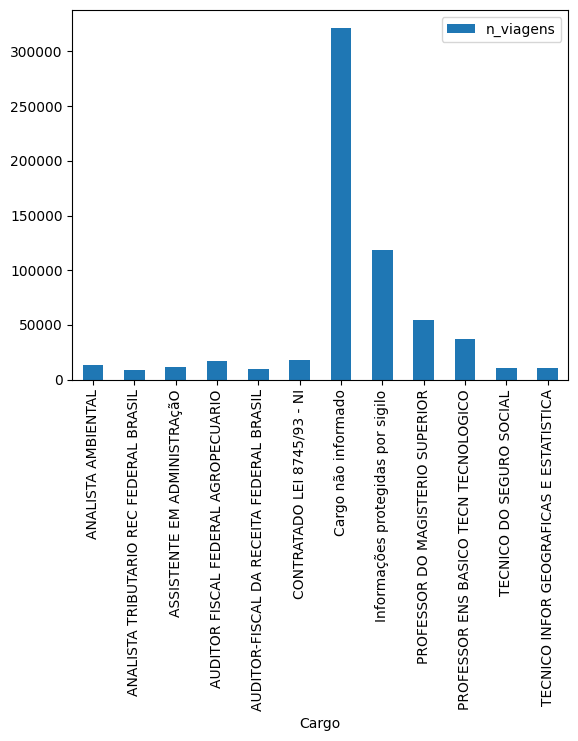

In [ ]:
df_final.plot(x='Cargo', y='n_viagens', kind='bar')

Text(0.5, 0.98, 'Despesas totais por cargo')

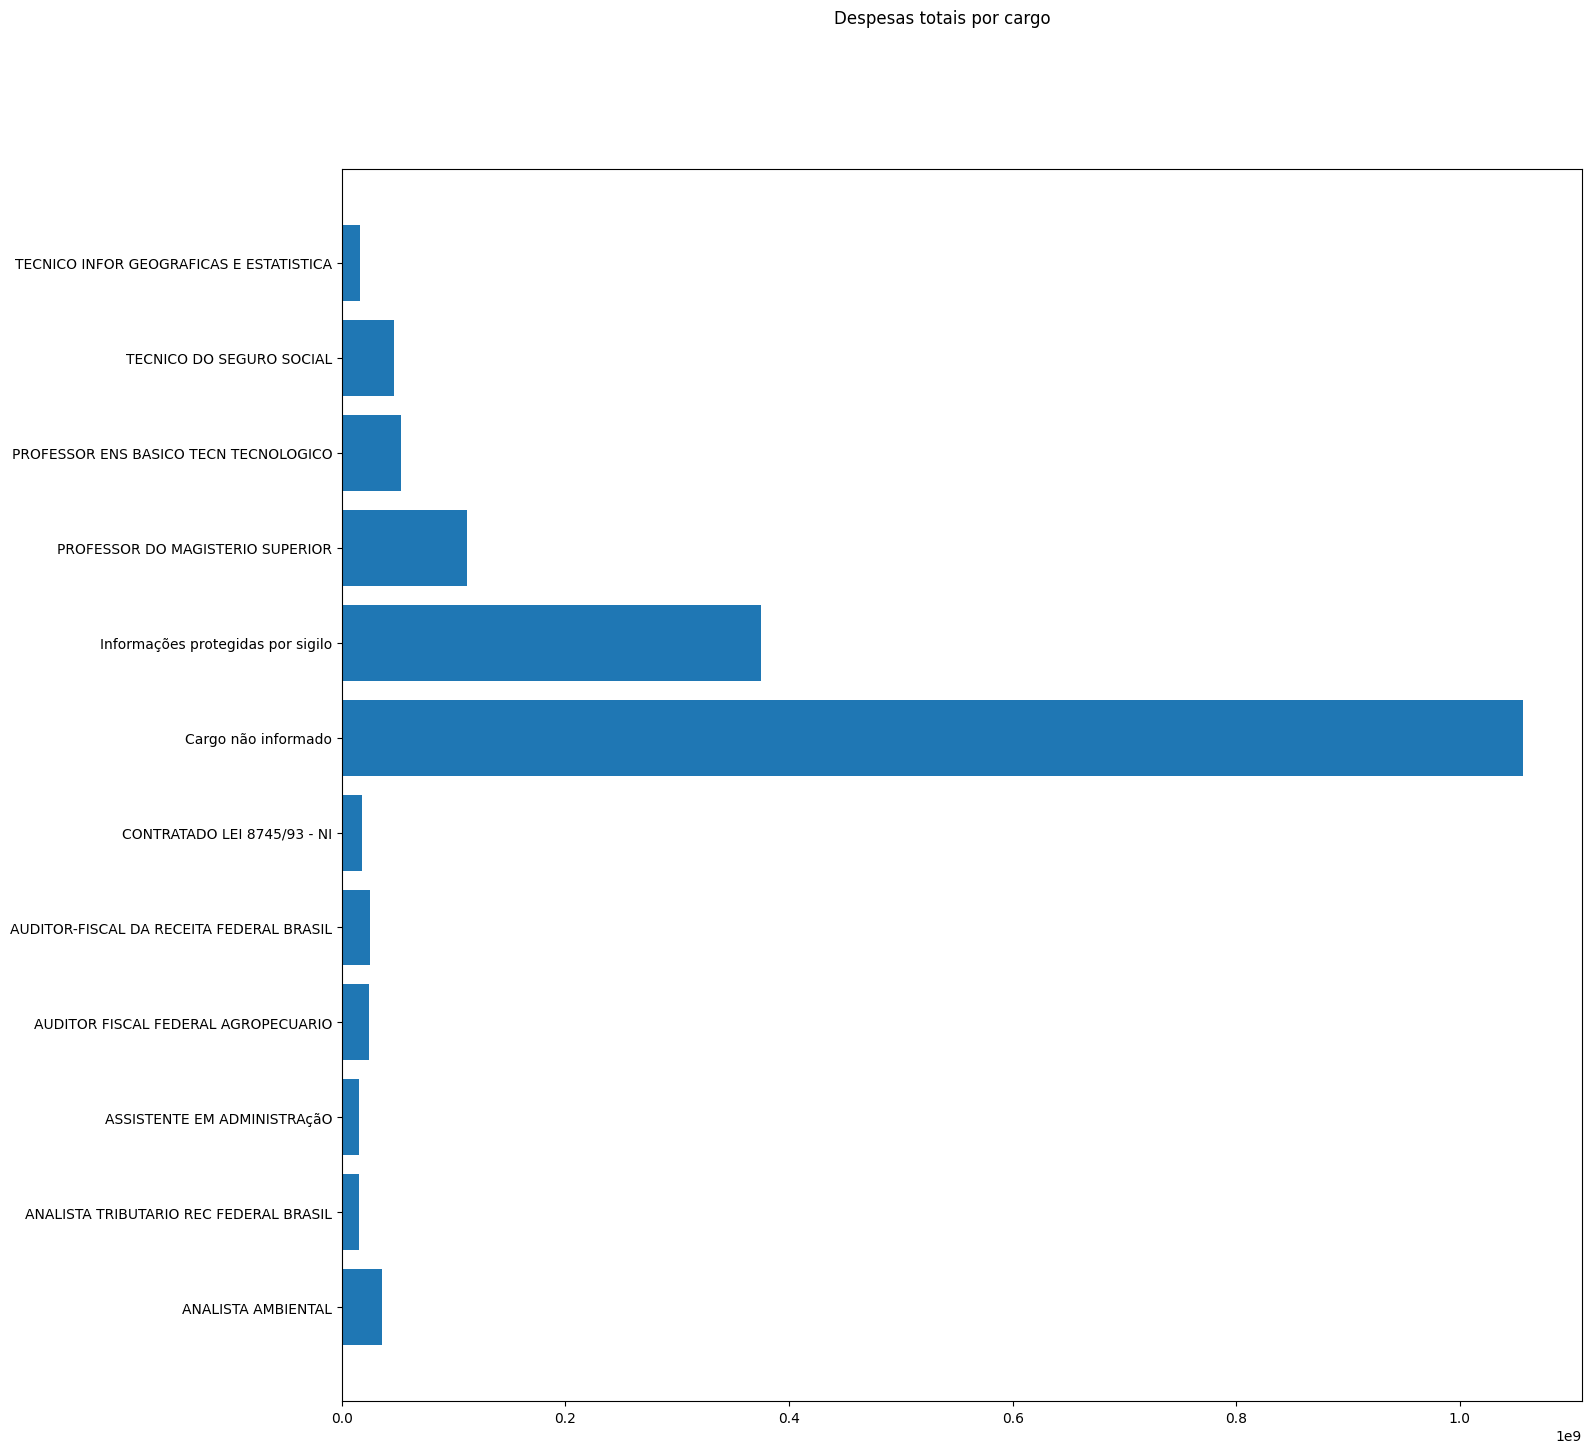

In [ ]:
fig, ax = plt.subplots(figsize=(16, 16))
ax.barh(df_final['Cargo'], df_final['despesas_totais'])
fig.suptitle('Despesas totais por cargo')